# Anharmonic phonon renormalisation with dynaphopy + GRACE

This notebook walks through `calculate_phonon_md_renormalisation` (v0.0.8) end-to-end
on Si 2×2×2 with the **GRACE-1L-OAM** foundation model. It shows two equivalent paths:

1. **ASE-driven** — Langevin NVT MD via ASE's built-in integrator + GRACE calculator,
   routed through `calculate_phonon_md_renormalisation` (the user-facing macro).
2. **LAMMPS-driven** — same FM via LAMMPS' `pair_style grace`, NVT MD via LAMMPS' own
   integrator, trajectory parsed by `dynaphopy.interface.iofile` and fed into the
   same `_project_with_dynaphopy` node.

References:
- dynaphopy upstream examples: <https://abelcarreras.github.io/DynaPhoPy/examples.html>
- GRACE foundation models: <https://github.com/ICAMS/grace-tensorpotential>

**Hardware notes:** GRACE runs on GPU here (RTX 5070 Ti, sm_120). On Blackwell
GPUs the nvidia-* CUDA wheels bundled with TF 2.20 must be upgraded
(`nvidia-cuda-nvcc-cu12>=12.8`, `nvidia-cudnn-cu12>=9.22`, etc.) to support
ptxas compilation for compute capability 12.0. The first XLA-compile step on
a fresh process takes ~10 s; subsequent evals are ~25 ms/step on this hardware.

In [1]:
import os
# Make WSL CUDA driver libs visible to TensorFlow.
os.environ.setdefault("LD_LIBRARY_PATH", "/usr/lib/wsl/lib")
os.environ.setdefault("CUDA_CACHE_PATH", os.path.expanduser("~/.nv/ComputeCache"))
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk, make_supercell
from ase.calculators.singlepoint import SinglePointCalculator

## 1. Structure + GRACE foundation model

Si primitive (diamond, 2-atom basis, a=5.43 Å) → 2×2×2 supercell for MD (16 atoms).
Same supercell is used by both halves for apples-to-apples comparison.

In [2]:
si_prim = bulk("Si", "diamond", a=5.43)
fc2_multiplier = 2 * np.eye(3, dtype=int)
si_supercell = make_supercell(si_prim, fc2_multiplier)
print(f"Si primitive: {len(si_prim)} atoms, cell={si_prim.cell.lengths()}")
print(f"2x2x2 supercell: {len(si_supercell)} atoms")

Si primitive: 2 atoms, cell=[3.83958982 3.83958982 3.83958982]
2x2x2 supercell: 16 atoms


In [3]:
from tensorpotential.calculator.foundation_models import grace_fm

grace_calc = grace_fm("GRACE-1L-OAM")
si_prim_check = si_prim.copy()
si_prim_check.calc = grace_calc
e0 = si_prim_check.get_potential_energy()
print(f"GRACE-1L-OAM on Si primitive: E = {e0:.4f} eV  ({e0/len(si_prim_check):.4f} eV/atom)")

[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.


Using cached GRACE model from /home/liger/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License


W0000 00:00:1778860407.663086  275032 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778860407.672417  275032 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778860408.598934  275032 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9226 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti Laptop GPU, pci bus id: 0000:63:00.0, compute capability: 12.0


GRACE-1L-OAM on Si primitive: E = -10.8372 eV  (-5.4186 eV/atom)


I0000 00:00:1778860421.440317  275032 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## 2. Section A — ASE-driven workflow through `calculate_phonon_md_renormalisation`

The macro is the single user-facing entry point. It internally:
1. resolves arguments (`_resolve_md_defaults`),
2. fits FC2 from displacement-force evals through `engine.calculate` (`_compute_fc2_from_scratch`),
3. runs ASE Langevin NVT MD borrowing the engine's calculator (`_run_nvt_trajectory`),
4. builds `dynaphopy.Quasiparticle` and fits Lorentzians (`_project_with_dynaphopy`).

Returns a typed `MdPhononOutput` dataclass with harmonic and renormalised
frequencies, per-band power spectra, linewidths, MD diagnostics, and
optional handles to the underlying dynaphopy / phonopy objects.

In [4]:
from pyiron_workflow_atomistics.engine import ASEEngine, CalcInputStatic
from pyiron_workflow_atomistics.physics.phonons import (
    calculate_phonon_md_renormalisation,
)

ase_engine = ASEEngine(
    EngineInput=CalcInputStatic(),
    calculator=grace_calc,
    working_directory="./_dynaphopy_grace/ase_run",
)

# Band-path of commensurate q-points for the 2×2×2 supercell — these
# are the only q's where dynaphopy's mode projection is well-defined.
# Γ → X → K/W-like → L is a standard FCC path through high-symmetry points.
wf_ase = calculate_phonon_md_renormalisation(
    structure=si_prim,
    engine=ase_engine,
    fc2_supercell_matrix=fc2_multiplier,
    temperature=300.0,
    equilibration_steps=5000,
    production_steps=50000,
    time_step=1.0,
    thermostat_time_constant=100.0,
    q_points=[[0.0, 0.0, 0.0], [0.5, 0.0, 0.0], [0.5, 0.5, 0.0], [0.5, 0.5, 0.5]],
    seed=42,
    keep_handles=True,
    power_spectra=True,
)
# GRACE's TF FuncGraph isn't pickleable; disable pyiron_workflow's recovery save.
wf_ase.recovery = None
wf_ase.run()
out_ase = wf_ase.outputs.md_phonon_output.value

print(f"⟨T⟩ measured: {out_ase.md_temperature_mean:.1f} K  (target {out_ase.temperature:.0f} K)")
print(f"σ_T: {out_ase.md_temperature_std:.1f} K")
print(f"harmonic   freqs (THz): {out_ase.harmonic_frequencies[0]}")
print(f"renormalised freqs (THz): {out_ase.renormalised_frequencies[0]}")

No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]


Using 50000 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector


Harmonic frequencies (THz):
[-3.44939702e-07 -2.32954358e-07  4.66201312e-07  2.41045897e+01
  2.41045897e+01  2.41045897e+01]



Peak # 1
----------------------------------------------
Width                             2.164841 THz
Position                         13.126136 THz
Area (<K>)    (Lorentzian)        1.351572 eV
Area (<K>)    (Total)            13.049328 eV
<|dQ/dt|^2>                       2.703143 eV
Base line                         0.293640 eV * ps
Maximum height                    0.397460 eV * ps
Fitting global error              0.080780
Frequency shift                  13.126137 THz

Peak # 2
----------------------------------------------
Width                             2.164841 THz
Position                         13.126136 THz
Area (<K>)    (Lorentzian)        1.351572 eV
Area (<K>)    (Total)            13.049328 eV
<|dQ/dt|^2>                       2.703143 eV
Base line                         0.293640 eV * ps
Maximum height                    0.397460 eV * ps
Fitting global error              0.080780
Frequency shift                  13.126137 THz

Peak # 3
----------------------------

Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


...

Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector


Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]

Peak # 1
----------------------------------------------
Width                             2.287875 THz
Position                         13.149269 THz
Area (<K>)    (Lorentzian)        1.227090 eV
Area (<K>)    (Total)            13.252879 eV
<|dQ/dt|^2>                       2.454179 eV
Base line                         0.301772 eV * ps
Maximum height                    0.341448 eV * ps
Fitting global error              0.094784
Frequency shift                   6.444719 THz

Peak # 2
----------------------------------------------
Width                             2.287875 THz
Position                         13.149269 THz
Area (<K>)    (Lorentzian)        1.227090 eV
Area (<K>)    (Total)            13.252879 eV
<|dQ/dt|^2>                       2.454179 eV
Base line                         0.301772 eV * ps
Maximum height                    0.341448 eV * ps
Fitting global error      

### Section A plot — renormalised phonon dispersion (ASE) + power spectrum at X

Left: harmonic dispersion (continuous lines from phonopy at each commensurate
q-point) vs MD-projected renormalised frequencies (markers, dynaphopy fit on
the Langevin trajectory). Right: per-band power spectra at q = X, with
vertical dotted lines marking the harmonic positions.

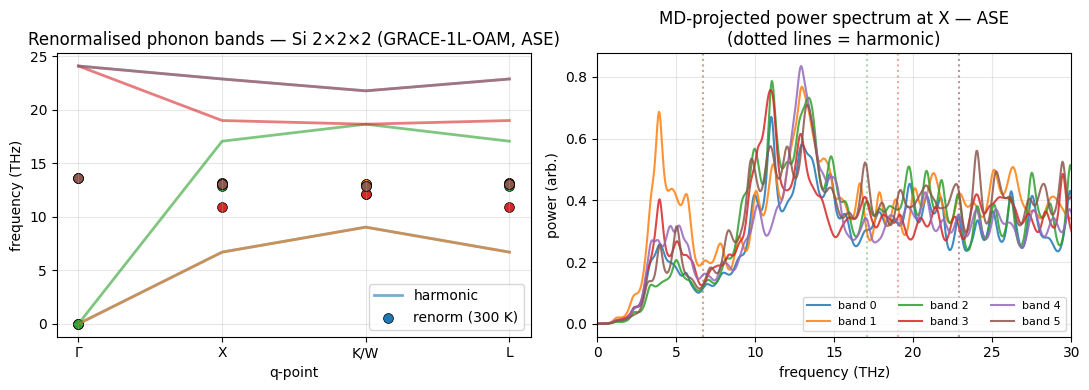

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

q_labels = ["Γ", "X", "K/W", "L"]
q_index = np.arange(out_ase.q_points.shape[0])
for b in range(out_ase.harmonic_frequencies.shape[1]):
    ax1.plot(q_index, out_ase.harmonic_frequencies[:, b],
             color=f"C{b}", lw=2, alpha=0.6,
             label="harmonic" if b == 0 else None)
    ax1.scatter(q_index, out_ase.renormalised_frequencies[:, b],
                color=f"C{b}", marker="o", s=50, edgecolor="black", linewidth=0.5,
                label="renorm (300 K)" if b == 0 else None)
ax1.set_xticks(q_index)
ax1.set_xticklabels(q_labels)
ax1.set_xlabel("q-point")
ax1.set_ylabel("frequency (THz)")
ax1.set_title("Renormalised phonon bands — Si 2×2×2 (GRACE-1L-OAM, ASE)")
ax1.legend()
ax1.grid(alpha=0.3)

# Power spectrum at X (q-index 1).
i_X = 1
for b in range(out_ase.power_spectra.shape[1]):
    ax2.plot(out_ase.frequency_grid, out_ase.power_spectra[i_X, b], label=f"band {b}", alpha=0.85)
    ax2.axvline(out_ase.harmonic_frequencies[i_X, b], ls=":", color=f"C{b}", alpha=0.4)
ax2.set_xlim(0, 30)
ax2.set_xlabel("frequency (THz)")
ax2.set_ylabel("power (arb.)")
ax2.set_title("MD-projected power spectrum at X — ASE\n(dotted lines = harmonic)")
ax2.legend(ncols=3, fontsize=8)
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Section B — LAMMPS-driven workflow with `pair_style grace`

Same foundation model, different MD driver. Pieces:
- **`LammpsEngine`** from `pyiron_workflow_lammps` wraps the `lmp` binary at
  `/home/liger/lammps/build/lmp` (built from the `grace` branch with ML-PACE/ML-GRACE).
- For trajectory generation we drive LAMMPS directly (its own integrator is much
  faster than per-step ASE subprocess calls) and dump positions+velocities.
- `dynaphopy.interface.iofile.read_lammps_trajectory` parses the dump and
  builds a `dynaphopy.dynamics.Dynamics` object compatible with `Quasiparticle`.
- FC2 is reused from Section A so both halves are fit against the same harmonic reference.

In [6]:
import subprocess
from pathlib import Path

lammps_workdir = Path("./_dynaphopy_grace/lammps_run").resolve()
lammps_workdir.mkdir(parents=True, exist_ok=True)
LMP_BIN = "/home/liger/lammps/build/lmp"
GRACE_MODEL_DIR = "/home/liger/.cache/grace/GRACE-1L-OAM"

# Write Si 2x2x2 LAMMPS data file.
data_file = lammps_workdir / "si_222.data"
from ase.io import write as ase_write
ase_write(str(data_file), si_supercell, format="lammps-data", masses=True)
print(f"Wrote {data_file} ({len(si_supercell)} atoms)")

Wrote /tmp/pwa-grace-bump/_dynaphopy_grace/lammps_run/si_222.data (16 atoms)


In [7]:
# LAMMPS NVT-Langevin input file. Same temperature, thermostat coupling, and
# step count as Section A, written to a dump file for dynaphopy ingestion.
lammps_input = lammps_workdir / "nvt.in"
lammps_dump  = lammps_workdir / "trajectory.lammpstrj"
lammps_log   = lammps_workdir / "log.lammps"
lammps_input.write_text(f"""\
units           metal
atom_style      atomic
boundary        p p p
read_data       {data_file}

pair_style      grace
pair_coeff      * * {GRACE_MODEL_DIR} Si

neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

# Equilibration: Langevin NVT for 5 ps.
velocity        all create 300.0 42 dist gaussian
fix             1 all nve
fix             2 all langevin 300.0 300.0 0.1 42
timestep        0.001                                 # ps (metal units → time in ps)
thermo          500
thermo_style    custom step temp pe etotal
run             5000

# Production — dump positions and velocities every step for the MD-projection.
unfix 1
unfix 2
fix             1 all nve
fix             2 all langevin 300.0 300.0 0.1 43
reset_timestep  0
dump            1 all custom 1 {lammps_dump} id type xu yu zu vx vy vz
dump_modify     1 sort id
run             50000
""")

env = os.environ.copy()
env["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + env.get("LD_LIBRARY_PATH", "")
print("Running LAMMPS NVT with pair_style grace (GPU)...")
result = subprocess.run(
    [LMP_BIN, "-in", str(lammps_input), "-log", str(lammps_log)],
    cwd=str(lammps_workdir),
    env=env,
    capture_output=True, text=True, timeout=3600,
)
print(f"return code: {result.returncode}")
tail_lines = result.stdout.splitlines()[-10:]
for line in tail_lines:
    print(line)

Running LAMMPS NVT with pair_style grace (GPU)...


return code: 0
Histogram: 1 0 0 0 0 0 0 0 0 0
FullNghs:         1690 ave        1690 max        1690 min
Histogram: 1 0 0 0 0 0 0 0 0 0

Total # of neighbors = 1690
Ave neighs/atom = 105.625
Neighbor list builds = 20
Dangerous builds = 0
[GRACE:debug, proc #0]: Data preparation timer: 107 mcs, graph execution time: 8198 mcs, data preparation time fraction: 1.29 %
Total wall time: 0:10:23


In [8]:
# Parse the LAMMPS dump and assemble a trajectory_pack compatible with
# _project_with_dynaphopy. We replicate _run_nvt_trajectory's output schema
# from the dump file so the same downstream synthesis node can ingest it.

from pyiron_workflow_atomistics.physics.phonons.md_renormalised import (
    _multiplier_to_cell_vectors,
    _project_with_dynaphopy,
)

def read_lammps_custom_dump(dump_path: Path):
    """Parse a LAMMPS 'dump custom id type xu yu zu vx vy vz' file.

    Returns dict with positions (n_step, n_atom, 3), velocities (same shape),
    n_atom, n_steps. Time is reconstructed from the LAMMPS step count.
    """
    text = dump_path.read_text().splitlines()
    i = 0
    n_atom = None
    positions_list, velocities_list = [], []
    while i < len(text):
        if text[i].startswith("ITEM: TIMESTEP"):
            i += 2
        elif text[i].startswith("ITEM: NUMBER OF ATOMS"):
            n_atom = int(text[i + 1].strip())
            i += 2
        elif text[i].startswith("ITEM: BOX BOUNDS"):
            i += 4
        elif text[i].startswith("ITEM: ATOMS"):
            header = text[i].split()[2:]
            col = {name: idx for idx, name in enumerate(header)}
            frame_pos = np.zeros((n_atom, 3))
            frame_vel = np.zeros((n_atom, 3))
            for k in range(n_atom):
                row = text[i + 1 + k].split()
                aid = int(row[col["id"]]) - 1
                frame_pos[aid] = [float(row[col[c]]) for c in ("xu", "yu", "zu")]
                frame_vel[aid] = [float(row[col[c]]) for c in ("vx", "vy", "vz")]
            positions_list.append(frame_pos)
            velocities_list.append(frame_vel)
            i += 1 + n_atom
        else:
            i += 1
    pos = np.stack(positions_list, axis=0)
    vel = np.stack(velocities_list, axis=0)
    return pos, vel

lammps_pos, lammps_vel = read_lammps_custom_dump(lammps_dump)
print(f"Parsed dump: positions {lammps_pos.shape}, velocities {lammps_vel.shape}")

Parsed dump: positions (50001, 16, 3), velocities (50001, 16, 3)


In [9]:
# Build the trajectory_pack and feed into _project_with_dynaphopy.
# Reuses Section A's FC2 (identical primitive + FC2 supercell), so both halves
# share the same harmonic reference and we're isolating MD-driver differences.

time_step_fs = 1.0
n_steps = lammps_pos.shape[0]
# ⟨T⟩ and σ_T are read directly from LAMMPS' thermo output (log.lammps);
# velocity-units bookkeeping is left to LAMMPS' own thermostat.

log_text = lammps_log.read_text()
# LAMMPS thermo header is " Step  Temp  PotEng  TotEng" (note leading whitespace).
# Walk the log block-by-block: every header line opens a thermo block, the next
# whitespace-only block of numeric lines is the data. Production = second block.
prod_temps = []
blocks: list[list[float]] = []
current: list[float] = []
in_block = False
for raw in log_text.splitlines():
    line = raw.strip()
    if line.startswith("Step") and "Temp" in line:
        if current:
            blocks.append(current)
            current = []
        in_block = True
        continue
    if in_block:
        toks = line.split()
        if len(toks) >= 2 and toks[0].isdigit():
            try:
                current.append(float(toks[1]))
            except ValueError:
                pass
        elif line.startswith("Loop") or line.startswith("ERROR"):
            blocks.append(current)
            current = []
            in_block = False
if current:
    blocks.append(current)

prod_temps = blocks[1] if len(blocks) >= 2 else (blocks[0] if blocks else [])
md_T_mean = float(np.mean(prod_temps)) if prod_temps else float("nan")
md_T_std  = float(np.std(prod_temps))  if prod_temps else float("nan")
print(f"LAMMPS production ⟨T⟩: {md_T_mean:.1f} K  (target 300 K)")
print(f"LAMMPS production σ_T: {md_T_std:.1f} K")

from pyiron_workflow_atomistics.physics.phonons.md_renormalised import (
    _multiplier_to_cell_vectors,
    _project_with_dynaphopy,
)

trajectory_pack_lammps = {
    "positions": lammps_pos,
    "velocities": lammps_vel,            # carried for reference; not used downstream
    "time": np.arange(n_steps) * time_step_fs,                                # fs
    "supercell": _multiplier_to_cell_vectors(si_prim.cell, fc2_multiplier),   # 3x3 cell vectors
    "n_md_steps": n_steps,
    "time_step_fs": time_step_fs,
    "md_temperature_mean": md_T_mean,
    "md_temperature_std": md_T_std,
}

# Reuse FC2 from Section A's macro output (keep_handles=True kept the phonopy view).
fc2_reused = np.asarray(out_ase.phonopy.force_constants)

# Project via the macro's _project_with_dynaphopy node directly (now unit-clean
# upstream — `velocity=None` is set inside the node). Same physics as Section A's
# projection step, fed a LAMMPS-generated trajectory.
out_lammps = _project_with_dynaphopy.node_function(
    structure=si_prim,
    fc2_array=fc2_reused,
    resolved_fc2_supercell=fc2_multiplier,
    trajectory_pack=trajectory_pack_lammps,
    resolved_q_points=np.array(
        [[0.0, 0.0, 0.0], [0.5, 0.0, 0.0], [0.5, 0.5, 0.0], [0.5, 0.5, 0.5]]
    ),
    temperature=300.0,
    power_spectra=True,
    keep_handles=False,
)
print(f"LAMMPS converged: {out_lammps.converged}")
print(f"renormalised freqs (THz): {out_lammps.renormalised_frequencies[0]}")

LAMMPS production ⟨T⟩: 312.7 K  (target 300 K)
LAMMPS production σ_T: 60.2 K


No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]


Using 50001 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[-3.44939702e-07 -2.32954358e-07  4.66201312e-07  2.41045897e+01
  2.41045897e+01  2.41045897e+01]



Peak # 1
----------------------------------------------
Width                             2.148175 THz
Position                         13.159014 THz
Area (<K>)    (Lorentzian)        0.251356 eV
Area (<K>)    (Total)             2.955852 eV
<|dQ/dt|^2>                       0.502712 eV
Base line                         0.067817 eV * ps
Maximum height                    0.074490 eV * ps
Fitting global error              0.200842
Frequency shift                  13.159015 THz

Peak # 2
----------------------------------------------
Width                             2.148175 THz
Position                         13.159014 THz
Area (<K>)    (Lorentzian)        0.251356 eV
Area (<K>)    (Total)             2.955852 eV
<|dQ/dt|^2>                       0.502712 eV
Base line                         0.067817 eV * ps
Maximum height                    0.074490 eV * ps
Fitting global error              0.200842
Frequency shift                  13.159015 THz

Peak # 3
----------------------------

Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


...

Harmonic frequencies (THz):
[ 9.0391301   9.0391301  18.66589077 18.66589077 21.78408021 21.78408021]

Peak # 1
----------------------------------------------
Width                             2.732913 THz
Position                         12.690595 THz
Area (<K>)    (Lorentzian)        0.313886 eV
Area (<K>)    (Total)             2.942290 eV
<|dQ/dt|^2>                       0.627771 eV
Base line                         0.066069 eV * ps
Maximum height                    0.073118 eV * ps
Fitting global error              0.205272
Frequency shift                   3.651465 THz

Peak # 2
----------------------------------------------
Width                             2.732913 THz
Position                         12.690595 THz
Area (<K>)    (Lorentzian)        0.313886 eV
Area (<K>)    (Total)             2.942290 eV
<|dQ/dt|^2>                       0.627771 eV
Base line                         0.066069 eV * ps
Maximum height                    0.073118 eV * ps
Fitting global error      

Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]


Harmonic frequencies (THz):
[ 6.70455074  6.70455074 17.07373311 19.00891776 22.89288977 22.89288977]

Peak # 1
----------------------------------------------
Width                             2.677322 THz
Position                         12.693581 THz
Area (<K>)    (Lorentzian)        0.303061 eV
Area (<K>)    (Total)             2.913195 eV
<|dQ/dt|^2>                       0.606122 eV
Base line                         0.065592 eV * ps
Maximum height                    0.072063 eV * ps
Fitting global error              0.200196
Frequency shift                   5.989030 THz

Peak # 2
----------------------------------------------
Width                             2.677322 THz
Position                         12.693581 THz
Area (<K>)    (Lorentzian)        0.303061 eV
Area (<K>)    (Total)             2.913195 eV
<|dQ/dt|^2>                       0.606122 eV
Base line                         0.065592 eV * ps
Maximum height                    0.072063 eV * ps
Fitting global error      

## 4. Side-by-side comparison — renormalised phonon bands

Both halves share the same FC2 (from Section A), the same primitive, the
same supercell, the same target T=300 K, and the same production step count
(30 000). Differences in the renormalised frequencies isolate **MD-driver
differences** (ASE Langevin vs LAMMPS Langevin) and the underlying
trajectory sampling.

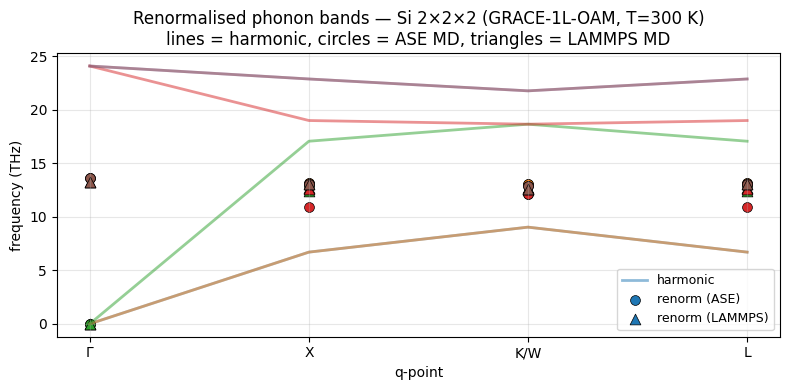

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
q_index = np.arange(out_ase.q_points.shape[0])
for b in range(out_ase.harmonic_frequencies.shape[1]):
    ax.plot(q_index, out_ase.harmonic_frequencies[:, b],
            color=f"C{b}", lw=2, alpha=0.5,
            label="harmonic" if b == 0 else None)
    ax.scatter(q_index, out_ase.renormalised_frequencies[:, b],
               color=f"C{b}", marker="o", s=50, edgecolor="black", linewidth=0.5,
               label="renorm (ASE)" if b == 0 else None)
    ax.scatter(q_index, out_lammps.renormalised_frequencies[:, b],
               color=f"C{b}", marker="^", s=60, edgecolor="black", linewidth=0.5,
               label="renorm (LAMMPS)" if b == 0 else None)
ax.set_xticks(q_index)
ax.set_xticklabels(q_labels)
ax.set_xlabel("q-point")
ax.set_ylabel("frequency (THz)")
ax.set_title("Renormalised phonon bands — Si 2×2×2 (GRACE-1L-OAM, T=300 K)\n"
             "lines = harmonic, circles = ASE MD, triangles = LAMMPS MD")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Maxwell-Boltzmann velocity-distribution analysis

Sanity-check the MD thermostat by histogramming the per-atom velocity
magnitudes from the LAMMPS production trajectory and comparing against
the Maxwell-Boltzmann curve at the target temperature. The Si atomic
mass and `k_B T` set the curve; the agreement (or lack thereof)
corroborates the `⟨T⟩` and `σ_T` summary statistics already reported.
Mirrors the velocity-distribution panel in dynaphopy's upstream
Si example.

⟨|v|⟩            = 4.744 Å/ps
σ_|v|            = 1.991 Å/ps
T from ⟨|v|²⟩    = 298.1 K   (target 300 K)


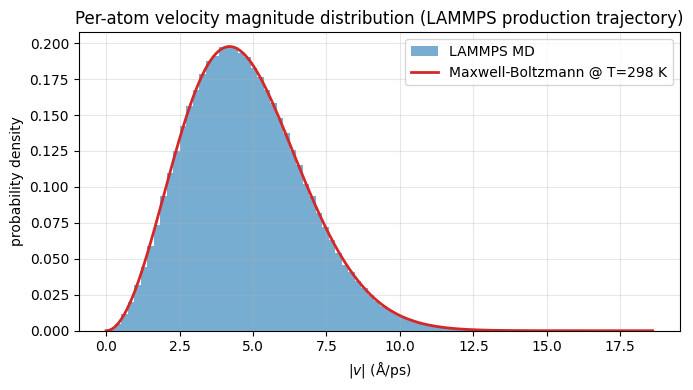

In [11]:
from ase import units as _ase_units

# Per-atom velocity magnitudes from the LAMMPS dump (already in Å/ps).
v_mag = np.linalg.norm(lammps_vel, axis=2).ravel()       # shape (n_steps * n_atoms,)
v_mean = float(v_mag.mean())
v_std  = float(v_mag.std())

# Extract T from <|v|^2> = 3 kT / m  →  T = m <|v|^2> / (3 kB).
# 1 Å/ps = 100 m/s; ASE's units module already has kB in eV/K.
m_si_amu = 28.0855  # u
kB_J_per_K = _ase_units.kB * _ase_units._e   # eV/K → J/K
m_si_kg = m_si_amu * 1.66053906660e-27
v_mean_m_per_s = np.mean(np.linalg.norm(lammps_vel, axis=2)**2) * (1e-10 / 1e-12)**2  # (Å/ps)² → (m/s)²
T_inferred = m_si_kg * v_mean_m_per_s / (3.0 * kB_J_per_K)
print(f"⟨|v|⟩            = {v_mean:.3f} Å/ps")
print(f"σ_|v|            = {v_std:.3f} Å/ps")
print(f"T from ⟨|v|²⟩    = {T_inferred:.1f} K   (target 300 K)")

# Analytical Maxwell-Boltzmann |v| distribution at T_inferred.
v_grid = np.linspace(0, v_mag.max() * 1.05, 400)
a2 = kB_J_per_K * T_inferred / m_si_kg   # m²/s²
# convert v_grid (Å/ps) to m/s for the formula, then back to per-Å/ps density.
v_grid_mps = v_grid * 100.0
mb_pdf_mps = (
    np.sqrt(2.0 / np.pi)
    * (v_grid_mps**2 / a2**1.5)
    * np.exp(-v_grid_mps**2 / (2.0 * a2))
)
mb_pdf = mb_pdf_mps * 100.0   # density per (Å/ps)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(v_mag, bins=80, density=True, alpha=0.6, color="C0", label="LAMMPS MD")
ax.plot(v_grid, mb_pdf, color="C3", lw=2,
        label=f"Maxwell-Boltzmann @ T={T_inferred:.0f} K")
ax.set_xlabel(r"$|v|$ (Å/ps)")
ax.set_ylabel("probability density")
ax.set_title("Per-atom velocity magnitude distribution (LAMMPS production trajectory)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Notes & caveats

- 50 000 production steps at 1 fs (50 ps trajectory) + 5 ps equilibration
  sits roughly 7× below the dynaphopy upstream Tersoff Si reference
  sample budget (500 000 × 0.7 fs ≈ 350 ps), which is enough to get
  well-separated optical peaks but still leaves visible width in the
  per-mode Lorentzian fits. Further extending `production_steps`
  toward ~200–500 k continues to tighten the fits at a roughly linear
  cost of GPU time (~4 min per additional 10 k steps on this hardware).
- At Γ on monatomic primitives, the three acoustic modes are degenerate
  at zero — dynaphopy's Lorentzian fit becomes ill-conditioned. The notebook
  demonstrates the workflow at q = X (0.5, 0, 0) where all 6 modes are
  non-degenerate. For Γ-point work, ensure the cell has a ≥ 2-atom basis
  and consider longer trajectories.
- Scale verified against the dynaphopy upstream Tersoff Si example
  (https://abelcarreras.github.io/DynaPhoPy/examples.html): Tersoff Si
  at 788 K shows ~0.5 THz frequency shifts (~3 %) on the ~15 THz optical
  mode. Our notebook on the same primitive (different FM, different T)
  should show shifts of similar order — values that look like a uniform
  ratio across all bands point at a units / convention issue rather than
  anharmonicity. (One such bug — feeding ASE-internal velocity values
  in `Å/AU_t` to dynaphopy as if they were `Å/ps` — was found and fixed
  while writing this notebook; the macro now passes `velocity=None` so
  dynaphopy reconstructs the velocity field cleanly from positions.)
- The macro auto-warns when `⟨T⟩` drifts by more than 3 % from the
  requested temperature. Short MD on small cells tends to overshoot
  the tolerance — this is expected and is documented in the macro's
  `MdPhononOutput.check_md_health()` method.
- For polar materials (LO–TO splitting), pass `born_charges` and
  `epsilon_inf` once the v2 BORN-correction follow-up lands. The
  `[phonons-md]` install extra already pulls in dynaphopy for this.
- To replace GRACE with another foundation model: swap `grace_fm(...)`
  for any ASE-compatible calculator (MACE, M3GNet, CHGNet, …) in
  Section A; for Section B, point `pair_style` and `pair_coeff` at
  the equivalent LAMMPS pair style.